In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
data0 = pd.read_excel('1_trend_data.xlsx')
data0

,date,SPY,QQQ,^SET.BK,GC=F,DIA,CL=F,^HSI,^N225,^FTSE
0,2003-12-01,2828.431400,1206.696752,641.150024,16063.703241,2405.164397,1194.705512,63986.576256,3801.354546,302129.109421
1,2003-12-02,2818.433492,1198.741342,646.640015,16087.041392,2394.208805,1226.552217,63764.108858,3819.171729,301837.571605
2,2003-12-03,2811.003053,1182.383390,659.429993,16078.046737,2396.527312,1237.997691,63296.659471,3790.198142,302037.825256
3,2003-12-04,2827.013252,1197.020809,659.289978,16079.570083,2412.448853,1246.336176,63346.183366,3840.009433,299994.262685
4,2003-12-08,2822.042668,1182.166852,664.359985,16187.153178,2417.601176,1277.933066,62430.082931,3722.300746,300913.367884
...,...,...,...,...,...,...,...,...,...,...
4695,2026-07-13,24969.836902,23722.295178,1627.900024,133220.017319,17475.621387,2604.406323,102907.008290,13839.023852,468637.088502
4696,2026-07-14,25193.822611,24116.810774,1626.030029,136087.457456,17577.368553,2658.683144,103948.718843,13960.918958,470522.739170
4697,2026-07-15,25248.394994,24008.403221,1630.209961,135271.803085,17588.034492,2662.620010,105305.583275,14175.254952,471091.830724
4698,2026-07-16,25173.143180,23671.581218,1635.290039,133645.148435,17593.605092,2647.351416,107050.716160,13836.159817,480401.367302


In [3]:
asset_name = list(data0.keys()[1:])
asset_N=len(asset_name)

value_M=np.array(data0[asset_name])
return_M=np.log(value_M[1:,:])-np.log(value_M[:-1,:])  #(value_M[1:,:]-value_M[:-1,:])/value_M[1:,:]

data1={'date': list(data0.loc[1:,'date'])}
for i in range(asset_N):
    data1.update({asset_name[i]: return_M[:,i]})
data1=pd.DataFrame(data1)
data1.dropna(inplace=True)
data1

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7564\3675954256.py:5: RuntimeWarning: invalid value encountered in log
  return_M=np.log(value_M[1:,:])-np.log(value_M[:-1,:])  #(value_M[1:,:]-value_M[:-1,:])/value_M[1:,:]


,date,SPY,QQQ,^SET.BK,GC=F,DIA,CL=F,^HSI,^N225,^FTSE
0,2003-12-02,-0.003541,-0.006615,0.008526,0.001452,-0.004565,0.026307,-0.003483,0.004676,-0.000965
1,2003-12-03,-0.002640,-0.013740,0.019586,-0.000559,0.000968,0.009288,-0.007358,-0.007615,0.000663
2,2003-12-04,0.005679,0.012304,-0.000212,0.000095,0.006622,0.006713,0.000782,0.013057,-0.006789
3,2003-12-08,-0.001760,-0.012487,0.007661,0.006668,0.002133,0.025036,-0.014567,-0.031133,0.003059
4,2003-12-09,-0.011773,-0.027281,0.004086,-0.000100,-0.007741,-0.014675,0.013670,0.006964,0.009878
...,...,...,...,...,...,...,...,...,...,...
4694,2026-07-13,-0.008585,-0.020062,0.003908,-0.027342,-0.003394,0.089164,0.000350,-0.017237,-0.001715
4695,2026-07-14,0.008930,0.016494,-0.001149,0.021296,0.005805,0.020626,0.010072,0.008770,0.004016
4696,2026-07-15,0.002164,-0.004505,0.002567,-0.006012,0.000607,0.001480,0.012969,0.015236,0.001209
4697,2026-07-16,-0.002985,-0.014129,0.003111,-0.012098,0.000317,-0.005751,0.016436,-0.024212,0.019569


In [4]:
test_end=data0.loc[len(data1),'date']
test_start=test_end-pd.Timedelta(days=30)
train_end=test_start-pd.Timedelta(days=1)
train_start=train_end-pd.Timedelta(days=365*10)

data_train=data1[(data1['date']>=train_start) & (data1['date']<=train_end)]  #train-test splitting
data_test=data1[(data1['date']>=test_start) & (data1['date']<=test_end)]

In [27]:
train_end

Timestamp('2026-06-14 00:00:00')

# Train Data

In [46]:
train_mean=data_train[asset_name].mean() #mean daily return
train_mean_vect=np.exp(np.array(train_mean))
train_mean

SPY        0.000673
QQQ        0.000929
^SET.BK    0.000044
GC=F       0.000534
DIA        0.000591
CL=F       0.000524
^HSI       0.000062
^N225      0.000461
^FTSE      0.000223
dtype: float64

In [47]:
train_cov=data_train[asset_name].cov() #mean daily return
train_cov_M=np.array(train_cov)
train_cov

,SPY,QQQ,^SET.BK,GC=F,DIA,CL=F,^HSI,^N225,^FTSE
SPY,0.000170,0.000193,0.000031,0.000024,0.000158,0.000100,0.000049,0.000042,0.000074
QQQ,0.000193,0.000252,0.000031,0.000030,0.000166,0.000100,0.000057,0.000046,0.000069
^SET.BK,0.000031,0.000031,0.000102,0.000003,0.000031,0.000028,0.000060,0.000047,0.000046
GC=F,0.000024,0.000030,0.000003,0.000135,0.000021,0.000045,0.000023,0.000006,0.000013
DIA,0.000158,0.000166,0.000031,0.000021,0.000164,0.000097,0.000045,0.000039,0.000077
CL=F,0.000100,0.000100,0.000028,0.000045,0.000097,0.001149,0.000073,0.000037,0.000079
^HSI,0.000049,0.000057,0.000060,0.000023,0.000045,0.000073,0.000254,0.000126,0.000090
^N225,0.000042,0.000046,0.000047,0.000006,0.000039,0.000037,0.000126,0.000221,0.000082
^FTSE,0.000074,0.000069,0.000046,0.000013,0.000077,0.000079,0.000090,0.000082,0.000162


In [48]:
n_step=10
step=(np.max(train_mean_vect)-np.min(train_mean_vect))/n_step
mean_target=np.arange(np.min(train_mean_vect),np.max(train_mean_vect)+step,step)
mean_target

array([1.00004442, 1.00013293, 1.00022144, 1.00030995, 1.00039845,
       1.00048696, 1.00057547, 1.00066398, 1.00075249, 1.000841  ,
       1.00092951, 1.00101802])

In [49]:
train_cov_inv=np.linalg.pinv(train_cov_M)
one_vect=np.ones(asset_N)
inter_M=np.linalg.pinv(np.array( [[one_vect.T@train_cov_inv@one_vect, one_vect.T@train_cov_inv@train_mean_vect], \
                                  [train_mean_vect.T@train_cov_inv@one_vect, train_mean_vect.T@train_cov_inv@train_mean_vect]]))

In [50]:
weight_vect=[] #base case: negative weight allow
for i in mean_target:
    l_cont_vect=inter_M@np.array([1, i])
    weight_vect.append(train_cov_inv@( l_cont_vect[0]*one_vect + l_cont_vect[1]*train_mean_vect ))

In [51]:
weight_mean=np.array([i@train_mean_vect for i in weight_vect])
weight_std=np.array([np.exp(np.sqrt(i.T@train_cov_M@i))-1 for i in weight_vect])

In [52]:
train_cov_M

array([[1.69887796e-04, 1.93392787e-04, 3.06546418e-05, 2.43601602e-05,
        1.58443082e-04, 1.00018913e-04, 4.93680807e-05, 4.15997547e-05,
        7.42156580e-05],
       [1.93392787e-04, 2.51589552e-04, 3.14849525e-05, 3.01796888e-05,
        1.65587090e-04, 1.00186349e-04, 5.67589108e-05, 4.58218280e-05,
        6.90290350e-05],
       [3.06546418e-05, 3.14849525e-05, 1.02455799e-04, 3.26490345e-06,
        3.08378201e-05, 2.76328759e-05, 6.03231354e-05, 4.70468925e-05,
        4.58602569e-05],
       [2.43601602e-05, 3.01796888e-05, 3.26490345e-06, 1.34625801e-04,
        2.12766610e-05, 4.48516428e-05, 2.29738568e-05, 6.32856092e-06,
        1.26711541e-05],
       [1.58443082e-04, 1.65587090e-04, 3.08378201e-05, 2.12766610e-05,
        1.63808905e-04, 9.74068381e-05, 4.47203417e-05, 3.89286795e-05,
        7.73851360e-05],
       [1.00018913e-04, 1.00186349e-04, 2.76328759e-05, 4.48516428e-05,
        9.74068381e-05, 1.14872786e-03, 7.26852121e-05, 3.73517901e-05,
        7.9

In [53]:
#If shorting is not allow
weight_vect2=[]
for i in weight_vect:
    weight_temp=i.copy()
    weight_temp[weight_temp<0]=0
    weight_temp=weight_temp/np.sum(weight_temp)
    weight_vect2.append(weight_temp)

weight_mean2=np.array([i@train_mean_vect for i in weight_vect2])
weight_std2=np.array([np.exp(np.sqrt(i.T@train_cov_M@i))-1 for i in weight_vect2])

# Test Data

In [54]:
test_mean=data_test[asset_name].mean() #mean daily return
test_mean_vect=np.exp(np.array(test_mean))
test_mean

SPY        0.002128
QQQ        0.000931
^SET.BK    0.001173
GC=F      -0.000945
DIA        0.002503
CL=F      -0.002085
^HSI       0.000991
^N225      0.002466
^FTSE      0.001219
dtype: float64

In [55]:
test_cov=data_test[asset_name].cov() #mean daily return
test_cov_M=np.array(test_cov)
test_cov

,SPY,QQQ,^SET.BK,GC=F,DIA,CL=F,^HSI,^N225,^FTSE
SPY,0.000094,0.000169,0.000063,0.000015,4.463712e-05,-0.000015,3.393170e-05,0.000128,-0.000057
QQQ,0.000169,0.000382,0.000112,0.000019,4.574259e-05,-0.000004,4.072111e-05,0.000298,-0.000125
^SET.BK,0.000063,0.000112,0.000122,0.000025,2.816298e-05,0.000021,1.733039e-05,0.000117,-0.000016
GC=F,0.000015,0.000019,0.000025,0.000263,1.796591e-05,-0.000187,-2.227601e-05,0.000093,0.000055
DIA,0.000045,0.000046,0.000028,0.000018,4.676349e-05,-0.000069,8.786785e-07,0.000047,-0.000015
CL=F,-0.000015,-0.000004,0.000021,-0.000187,-6.920641e-05,0.001235,1.704689e-04,-0.000110,-0.000134
^HSI,0.000034,0.000041,0.000017,-0.000022,8.786785e-07,0.000170,2.663901e-04,0.000060,0.000031
^N225,0.000128,0.000298,0.000117,0.000093,4.717268e-05,-0.000110,5.958483e-05,0.000557,0.000025
^FTSE,-0.000057,-0.000125,-0.000016,0.000055,-1.528930e-05,-0.000134,3.096574e-05,0.000025,0.000244


In [56]:
weight_mean3=np.array([i@test_mean_vect for i in weight_vect]) # if shorting allow
weight_std3=np.array([np.exp(np.sqrt(i.T@test_cov_M@i))-1 for i in weight_vect])

In [57]:
weight_std

array([0.00820848, 0.00761309, 0.00722758, 0.00708585, 0.00720215,
       0.0075647 , 0.00814104, 0.00889017, 0.009773  , 0.01075725,
       0.01181816, 0.01293745])

In [58]:
weight_mean4=np.array([i@test_mean_vect for i in weight_vect2]) # if shorting not allow
weight_std4=np.array([np.exp(np.sqrt(i.T@test_cov_M@i))-1 for i in weight_vect2])

# Plot Efficient Frontier

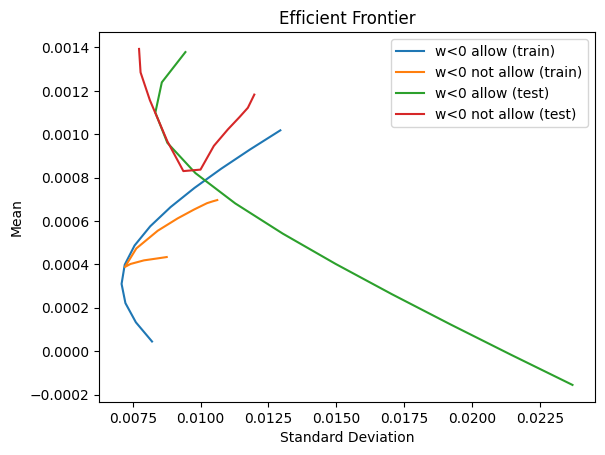

In [59]:
plt.plot(weight_std, weight_mean-1, label='w<0 allow (train)')
plt.plot(weight_std2, weight_mean2-1, label='w<0 not allow (train)')
plt.plot(weight_std3, weight_mean3-1, label='w<0 allow (test)')
plt.plot(weight_std4, weight_mean4-1, label='w<0 not allow (test)')
plt.title('Efficient Frontier')
plt.xlabel('Standard Deviation')
plt.ylabel('Mean')
plt.legend()
plt.show()

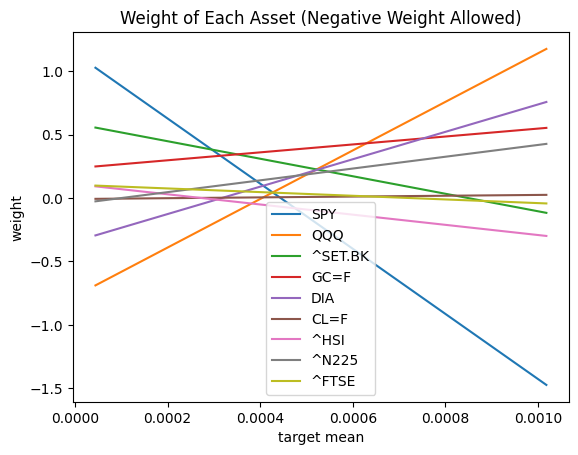

In [60]:
plt.figure()
for i in range(asset_N):
    plt.plot(mean_target-1,[weight_vect[j][i] for j in range(n_step+2)], label=asset_name[i])
plt.xlabel('target mean')
plt.ylabel('weight')
plt.title('Weight of Each Asset (Negative Weight Allowed)')
plt.legend()
plt.show()

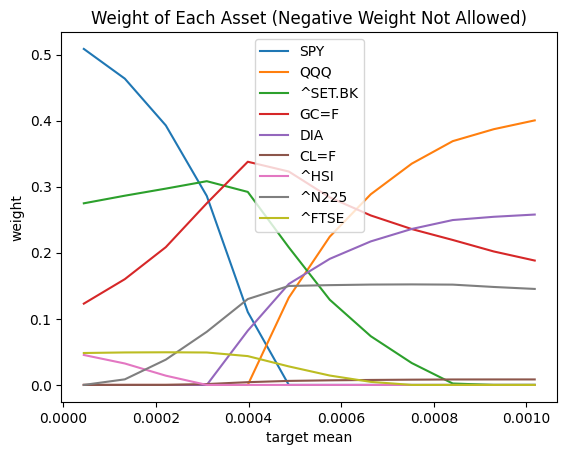

In [61]:
plt.figure()
for i in range(asset_N):
    plt.plot(mean_target-1,[weight_vect2[j][i] for j in range(n_step+2)], label=asset_name[i])
plt.xlabel('target mean')
plt.ylabel('weight')
plt.title('Weight of Each Asset (Negative Weight Not Allowed)')
plt.legend()
plt.show()